# **Exploratory Data Analysis for Machine Learning**

**Dataset:** https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

**Objective:**
Gaining insight to get more understanding from the dataset

#**0. Import Libraries and Data**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib.colors import ListedColormap

pd.set_option('display.max_columns', None)


In [ ]:
file_id = "1Jhvpv41yrreTbNShSpJNMQt9ShIMdxN5"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)

pd.set_option('display.max_columns', None)

#**1.A. Data Exploration for Visualization and Data Cleaning**

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

##**Data Cleaning: Missing Values and Duplicated Data**

###**Handling Missing Values**

In [ ]:
df = df.replace(['', ' ', 'NA', 'N/A', 'null','NaN'], np.nan)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


The 'Total Charges' and 'Churn Reasons' columns contain missing data. Let us proceed by re-verifying the extent of these missing values on a column-by-column basis.

####**Missing Data Patterns within the Total Charges Column**



In [ ]:
df[df['Total Charges'].isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [ ]:
df[df['Tenure Months'] == 0].count()

,0
CustomerID,11
Count,11
Country,11
State,11
City,11
Zip Code,11
Lat Long,11
Latitude,11
Longitude,11
Gender,11


####**Insights into Missing Data Patterns within the Total Charges Column**

The 'Total Charges' column was found to contain blank entries. Considering the nature of this customer-level reporting, we first examined the subscription duration. It was determined that **customers with zero total charges are in their first month of service (Tenure = 0)**, meaning these values represent individuals who have not yet completed a billing cycle.

####**Missing Values within Churn Reason Column**

In [ ]:
display(df['Churn Reason'].value_counts())

,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


In [ ]:
df[df.isna().any(axis=1)]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
1869,7590-VHVEG,1,United States,California,Los Angeles,90001,"33.973616, -118.24902",33.973616,-118.249020,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,27,3964,NaN
1870,5575-GNVDE,1,United States,California,Los Angeles,90002,"33.949255, -118.246978",33.949255,-118.246978,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0,61,3441,NaN
1871,7795-CFOCW,1,United States,California,Los Angeles,90004,"34.076259, -118.310715",34.076259,-118.310715,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,66,4307,NaN
1872,1452-KIOVK,1,United States,California,Los Angeles,90007,"34.027337, -118.28515",34.027337,-118.285150,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No,0,43,4459,NaN
1873,6713-OKOMC,1,United States,California,Los Angeles,90008,"34.008293, -118.346766",34.008293,-118.346766,Female,No,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No,0,51,2013,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
100 * len(df[(df['Churn Reason'] == "Don't know") | (df['Churn Reason'].isnull())]) / len(df)

75.6495811443987

#### **Insight Missing Values Kolom Total Charges:**

Regarding the 'Total Charges' column, the missing values are highly insightful. However, further analysis of the dataset reveals that the **'Churn Reason'** column contains over 75% missing data. Given that this exceeds the 20% threshold for reliable analysis, **the column must be discarded.**

###**Handling Duplicated Data**

In [ ]:
len(df)

7043

In [ ]:
len(df.drop_duplicates())

7043

In [ ]:
len(df.drop_duplicates()) / len(df)

1.0

#**1. B. Insight of Data Exploration for Data Visualization:**

There are 32 columns in total, categorized into the following detailed segments:

- **Churn-Related Data:**
Includes variables such as Churn Label, Churn Value, Churn Score, CLTV, and Churn Reason to identify customers who have discontinued the service.

- **Service Utilization:**
Covers the various services adopted by customers, including Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, and streaming options for TV and movies.

- **Account Specifications:**
Details regarding the customer's financial and contractual status, such as Contract type, Paperless Billing, Payment Method, Monthly Charges, and Total Charges.

- **Subscription Duration:**
Quantified by the Tenure Months column, indicating the length of time a customer has remained with the provider.

- **Revenue Metrics:**
The Customer Lifetime Value (CLTV) represents the total revenue generated from an individual throughout their entire association with the service.

- **Geographic Distribution:**
Spatial data encompassing Country, State, City, Zip Code, and precise coordinates including Lat Long, Latitude, and Longitude.

- **Demographic Profiles:** Personal information concerning the customer, specifically Gender, Senior Citizen status, Partner, and Dependents.

#**Insight of Data Cleaning:**

**Missing Value**

- **The Churn Reason column must be discarded** due to a missing value rate exceeding the 20% threshold.

- **The Total Charges column will be retained**, as the blank entries signify new customers who have not yet reached their initial payment deadline.

**Duplicate Value**

No duplicate values were identified within the dataset.


#**2.A. Visualization of Dataset Distribution**

**Case Study: What is the distribution of continuous data within the Telco Churn dataset?**

To assess data dispersion and identify the presence of outliers, each continuous and numerical variable will be visualized using histograms, boxplots, and probability plots. The specific columns under analysis are:

- **Tenure Months:** Represents the duration for which a customer has utilized the services.

- **Monthly Charges:** Denotes the monthly service fees incurred, contingent upon the specific services selected by the customer.

- **Total Charges:** Indicates the aggregate expenditure paid by the customer, calculated based on service types and the length of their subscription.

- **Churn Score:** Signifies the probability of a customer discontinuing the service, measured on a scale ranging from 0 to 100.

- **CLTV (Customer Lifetime Value):** An estimation of the total projected revenue derived from a customer throughout their entire subscription period.

Furthermore, any remaining columns with integer or float data types will be converted to object types. This is because their numerical values serve merely as symbolic representations rather than quantitative measures.

In [ ]:
df[['Churn Value', 'Count', 'Zip Code']] = df[['Churn Value', 'Count', 'Zip Code']].astype(object)
df[['Churn Score', 'Total Charges']] = df[['Churn Score', 'Total Charges']].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   object 
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   object 
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
def check_plot(df):
    num_cols = df.select_dtypes(include='number').columns

    for col in num_cols:
        x = df[col].dropna()

        plt.figure(figsize=(16, 4))

        # Histogram
        plt.subplot(1, 3, 1)
        sns.histplot(x, bins=30)
        plt.title(f'Histogram {col}')

        # Q-Q plot
        plt.subplot(1, 3, 2)
        stats.probplot(x, dist="norm", plot=plt)
        plt.ylabel(f'Variable quantiles {col}')

        # Boxplot
        plt.subplot(1, 3, 3)
        sns.boxplot(y=x)
        plt.title(f'Boxplot {col}')

        plt.tight_layout()
        plt.show()

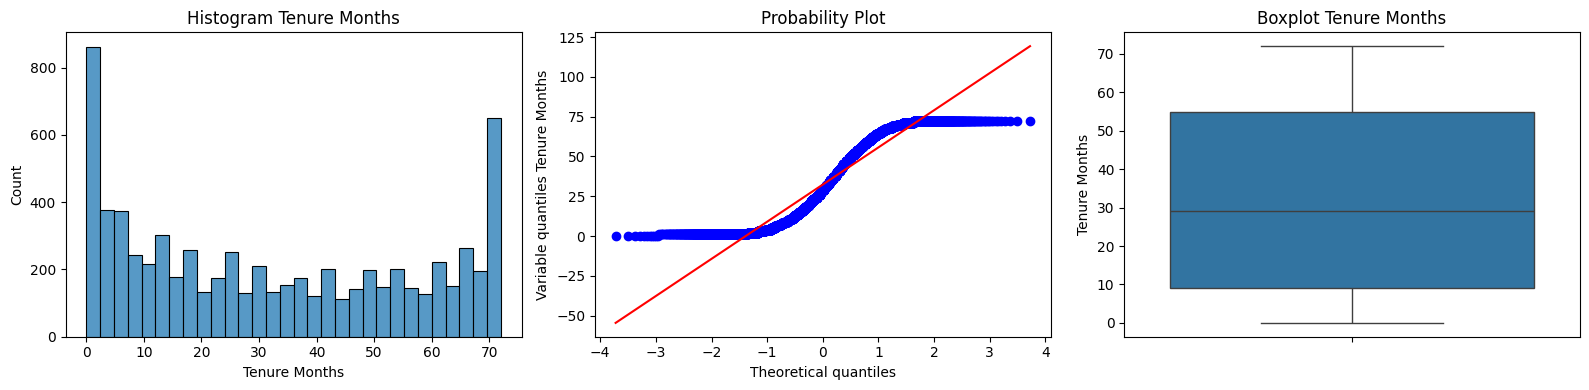

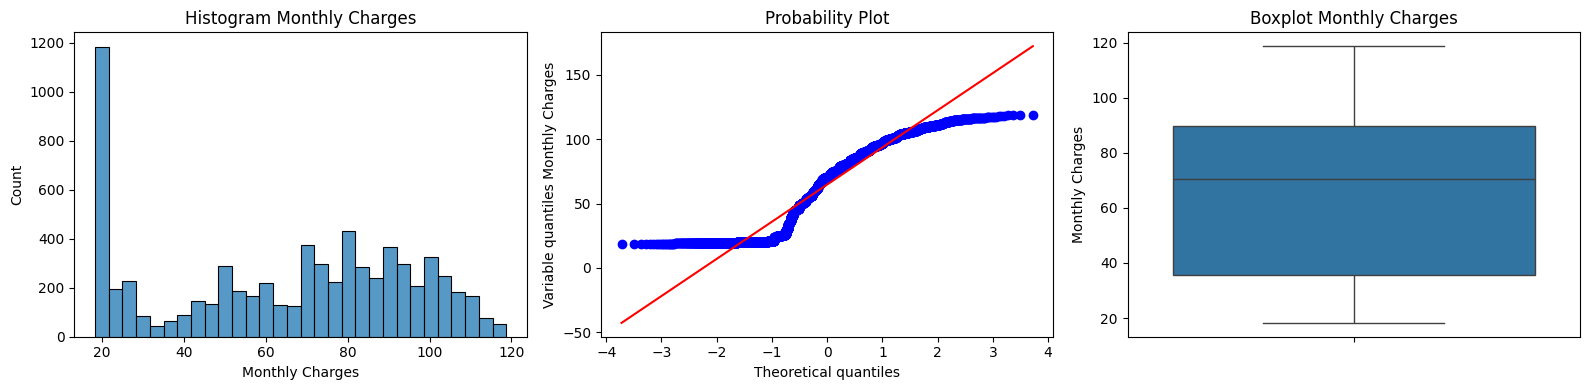

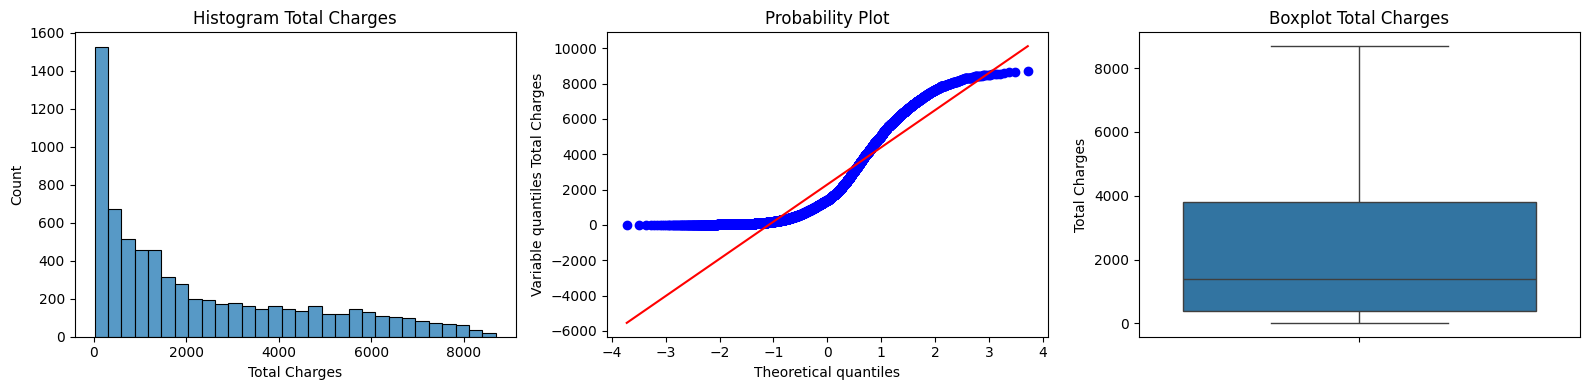

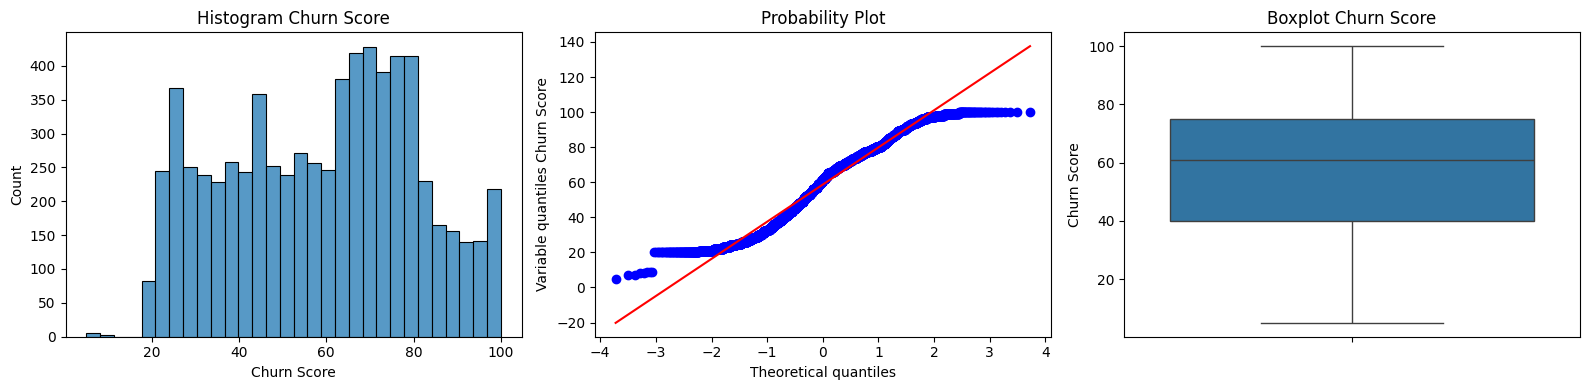

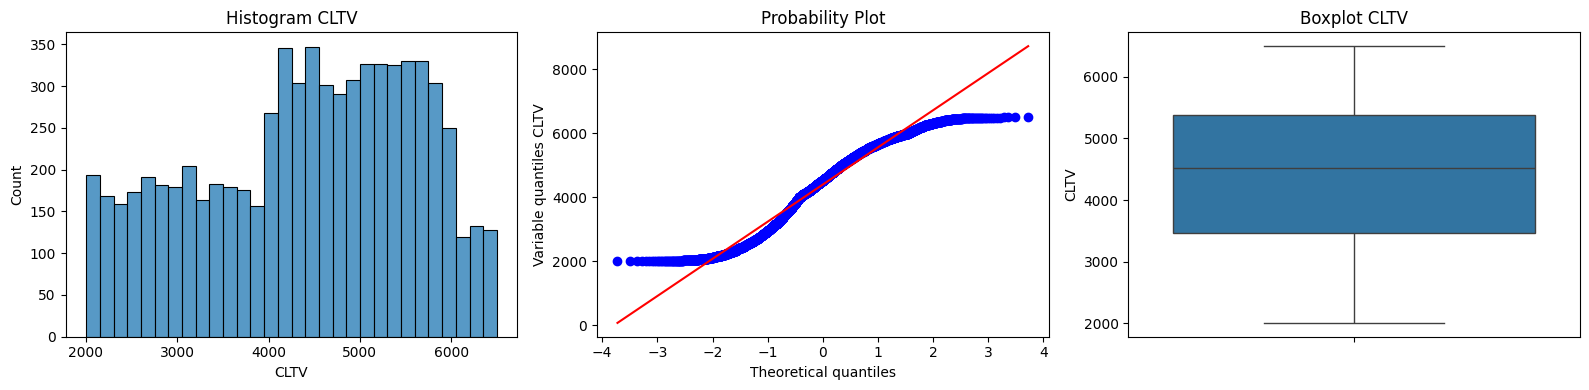

In [ ]:
df_fil = df[['Tenure Months',
       'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']]

check_plot(df_fil)

#**2.B. Insights from the Data Distribution Visualizations:**

- **Absence of Anomalies:** Based on the boxplot analysis, no extreme statistical values or outliers were identified across the variables.

- **Customer Longevity Patterns:** The histograms for Total Charges, Monthly Charges, and Tenure Months indicate a significant concentration of new subscribers with a tenure of fewer than five months.

- **Distribution Characteristics:** Every examined column exhibits a non-normal distribution, departing from the standard bell curve.

- **Churn Probability Density:** The Churn Score histogram reveals that the highest density of customers falls within the 70–80 range, suggesting a substantially high probability of service discontinuation among this group.

#**3.A. Bivariate Data Visualization**

**Case Study: How are customers distributed within the CLTV-Churn Score risk matrix?**

- **Variable Definition:** The CLTV (Customer Lifetime Value) column quantifies the aggregate revenue generated from a customer throughout their association with the service, while the Churn Score indicates their propensity to discontinue using the application.

- **Analytical Objective:** This bivariate analysis examines the distribution of customers across the Churn Score and CLTV matrix to determine the necessary interventions for customer retention.

- **Strategic Application:** By mapping these variables, the business can identify specific segments that require targeted loyalty programs and pinpoint customers with high potential for value development.

In [ ]:
df['Churn Score Grouped'] = df['Churn Score'].apply(lambda x: "High-Risk" if x < 101 and x >= 75
                                                    else "Higher Med-Risk" if x < 75 and x >= 50
                                                    else "Lower Med-Risk" if x < 50 and x >= 25
                                                    else "Low-Risk")

df['CLTV Grouped'] = df['CLTV'].apply(lambda x: "High-Value" if x < 6600 and x >= 5000
                                                    else "Higher Med-Value" if x < 5000 and x >= 4000
                                                    else "Lower Med-Value" if x < 4000 and x >= 3000
                                                    else "Low-Value")

In [ ]:
df_cltv_grp = df['CLTV Grouped'].value_counts().reset_index()
df_cltv_grp['Range Value'] = ['5k+', '4-5k', '3-4k', '2-3k']
df_cltv_grp = df_cltv_grp[
    ['CLTV Grouped', 'Range Value', 'count']
]

order = [
    'High-Value',
    'Higher Med-Value',
    'Lower Med-Value',
    'Low-Value'
]

df_cltv_grp['CLTV Grouped'] = pd.Categorical(
    df_cltv_grp['CLTV Grouped'],
    categories=order,
    ordered=True
)

df_cltv_grp = df_cltv_grp.sort_values('CLTV Grouped')


In [ ]:
df_churn_grp = df['Churn Score Grouped'].value_counts().reset_index()
df_churn_grp['Range Score'] = ['50-75', '25-50','100 - 75', '0-25']
df_churn_grp = df_churn_grp[
    ['Churn Score Grouped', 'Range Score', 'count']
]

order = [
    'High-Risk',
    'Higher Med-Risk',
    'Lower Med-Risk',
    'Low-Risk'
]

df_churn_grp['Churn Score Grouped'] = pd.Categorical(
    df_churn_grp['Churn Score Grouped'],
    categories=order,
    ordered=True
)

df_churn_grp = df_churn_grp.sort_values('Churn Score Grouped')

In [ ]:
df_cltv_grp

,CLTV Grouped,Range Value,count
0,High-Value,5k+,2574
1,Higher Med-Value,4-5k,2102
2,Lower Med-Value,3-4k,1188
3,Low-Value,2-3k,1179


In [ ]:
df_churn_grp

,Churn Score Grouped,Range Score,count
2,High-Risk,100 - 75,1880
0,Higher Med-Risk,50-75,2630
1,Lower Med-Risk,25-50,2112
3,Low-Risk,0-25,421


In [ ]:
df['Churn_bin'] = pd.cut(
    df['Churn Score'],
    bins=[0, 25, 50, 75, 100],
    labels=['0–25', '25–50', '50–75', '75–100']
)

df['CLTV_bin'] = pd.cut(
    df['CLTV'],
    bins=[2000, 3000, 4000, 5000, 7000],
    labels=['2–3k', '3–4k', '4–5k', '5k+']
)

In [ ]:
heatmap_data = pd.crosstab(
    df['CLTV_bin'],
    df['Churn_bin']
)

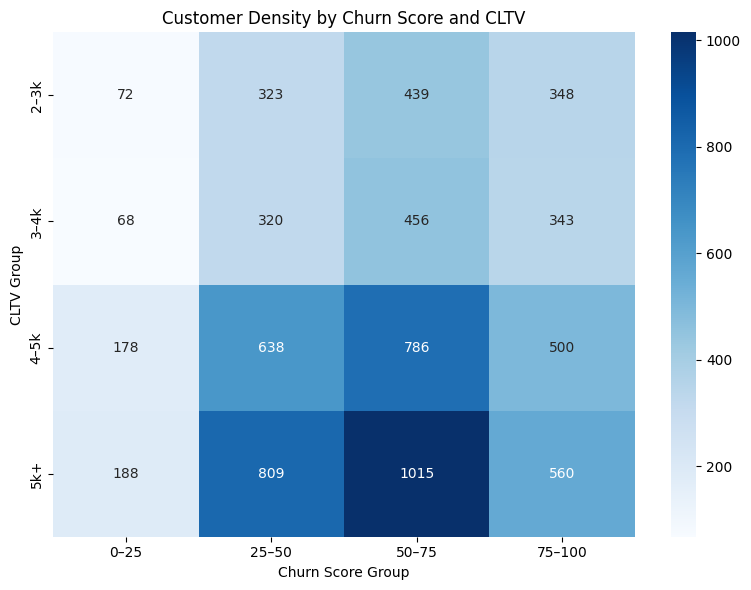

Total customer: 7043


In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Customer Density by Churn Score and CLTV')
plt.xlabel('Churn Score Group')
plt.ylabel('CLTV Group')
plt.tight_layout()
plt.show()

tot_cst = df['CustomerID'].value_counts().sum()
print(f"Total customer: {tot_cst}")

#**3.B. Insights from Bivariate Data Visualization:**

- **Customer Density:** The highest concentration of the customer base is situated within the segment characterized by both high Churn Scores and high CLTV.

- **Top Retention Priority:** Approximately 2,800 individuals exhibit elevated Churn Scores alongside high CLTV; consequently, this group should be classified as a "Top Retention Priority" to mitigate the risk of losing high-value assets.

- **Top Loyal Champions:** A cohort of 1,800 customers possesses low Churn Scores and high CLTV, warranting their inclusion in the "Top Loyal Champions" category due to their stability and significant financial contribution.

- **Low Priority:** There are 1,600 customers with high Churn Scores but low CLTV; these should be designated as "Low Priority" in terms of resource allocation.

- **Niche Segment:** A smaller group of 783 customers displays low values in both metrics and is categorized as "Niche." This segment may benefit from tailored interventions aimed at incrementally enhancing their lifetime value.

- **Strategic Framework:** The categorical matrix and detailed classification definitions are attached to guide subsequent strategic actions and operational decision-making.

### Churn Strategy Matrix

The following table and supplementary notes outline the customer segmentation strategy based on the CLTV and Churn Score matrix:

| CLTV Range | 0–25 | 25–50 | 50–75 | 75–100 |
|------------|------|-------|-------|--------|
| **2–3k**   | Niche | Niche | Low Priority | Low Priority |
| **3–4k**   | Niche | Niche | Low Priority | Low Priority |
| **4–5k**   | Loyal Champions | Loyal Champions | Retention Priority | Retention Priority |
| **5k+**    | Loyal Champions | Loyal Champions | Retention Priority | Retention Priority |


Note:
- **Retention Priority:**  Demands immediate, high-stakes intervention through bespoke offers and personalized technical support to prevent imminent churn of high-value assets.

- **Loyal Champions:**  Focus on sustaining high satisfaction levels; these individuals should be prioritized for upselling opportunities or exclusive loyalty programs.

- **Low Priority:**  These accounts represent minimal strategic value; they may be allowed to churn, or alternatively, be managed via low-cost, automated retention workflows.

- **Niche:**  This segment requires consistent monitoring to identify opportunities for incremental growth in their lifetime value.

#**4.A. Categorical Data Visualization**

**Case Study: Identifying the Most Utilized Services Among the Customer Base**

- **Service Overview:** The application offers a suite of nine distinct services. Customers have the flexibility to subscribe to a single service or multiple options simultaneously, contingent upon their individual preferences.

- **Analytical Objective:** This segment aims to identify the services with the highest adoption rates through a systematic quantitative approach.

**Methodological Process:**

- **Data Encoding:** All service-related columns will undergo binary encoding, where "Yes" is represented by 1 and "No" by 0.

- **Comparative Matrix:** A matrix will be constructed to contrast the proportion of services adopted versus those declined by the users.

- **Visual Representation:** The resulting matrix will be visualized using a stacked bar chart to illustrate the relative distribution of service usage across the entire dataset.


In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason', 'Churn Score Grouped',
       'CLTV Grouped', 'Churn_bin', 'CLTV_bin'],
      dtype='object')

In [ ]:
services = ['Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies',
]

df_services = df[services]

In [ ]:
for column in df_services.columns:
    print(f"============= {column} =================")
    display(df_services[column].value_counts())
    print()

============= Phone Service =================


,count
Phone Service,
Yes,6361
No,682



============= Multiple Lines =================


,count
Multiple Lines,
No,3390
Yes,2971
No phone service,682



============= Internet Service =================


...

,count
Tech Support,
No,3473
Yes,2044
No internet service,1526



============= Streaming TV =================


,count
Streaming TV,
No,2810
Yes,2707
No internet service,1526



============= Streaming Movies =================


,count
Streaming Movies,
No,2785
Yes,2732
No internet service,1526


In [ ]:
df['Phone Service'] = df['Phone Service'].replace({'Yes': '1', 'No': '0'})
df['Multiple Lines'] = df['Multiple Lines'].replace({'Yes': '1', 'No': '0', 'No phone service': '0'})
df['Internet Service'] = df['Internet Service'].replace({'Fiber optic': '1', 'DSL': '1', 'No': '0'})
df['Online Security'] = df['Online Security'].replace({'Yes': '1', 'No': '0', 'No internet service': '0'})
df['Online Backup'] = df['Online Backup'].replace({'Yes': '1', 'No': '0', 'No internet service': '0'})
df['Device Protection'] = df['Device Protection'].replace({'Yes': '1', 'No': '0', 'No internet service': '0'})
df['Tech Support'] = df['Tech Support'].replace({'Yes': '1', 'No': '0', 'No internet service': '0'})
df['Streaming TV'] = df['Streaming TV'].replace({'Yes': '1', 'No': '0', 'No internet service': '0'})
df['Streaming Movies'] = df['Streaming Movies'].replace({'Yes': '1', 'No': '0', 'No internet service': '0'})

df_services = df[services]

In [ ]:
for column in df_services.columns:
    print(f"============= {column} =================")
    display(df_services[column].value_counts())
    print()

============= Phone Service =================


,count
Phone Service,
1,6361
0,682



============= Multiple Lines =================


,count
Multiple Lines,
0,4072
1,2971



============= Internet Service =================


...

,count
Tech Support,
0,4999
1,2044



============= Streaming TV =================


,count
Streaming TV,
0,4336
1,2707



============= Streaming Movies =================


,count
Streaming Movies,
0,4311
1,2732


In [ ]:
df_services_int = df_services.astype(int)
df_services_int.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Phone Service      7043 non-null   int64
 1   Multiple Lines     7043 non-null   int64
 2   Internet Service   7043 non-null   int64
 3   Online Security    7043 non-null   int64
 4   Online Backup      7043 non-null   int64
 5   Device Protection  7043 non-null   int64
 6   Tech Support       7043 non-null   int64
 7   Streaming TV       7043 non-null   int64
 8   Streaming Movies   7043 non-null   int64
dtypes: int64(9)
memory usage: 495.3 KB


In [ ]:
summary = pd.DataFrame({
    'Yes (%)': df_services_int.mean() * 100,
    'No (%)': (1 - df_services_int.mean()) * 100
})

summary = summary.round(2)
summary

,Yes (%),No (%)
Phone Service,90.32,9.68
Multiple Lines,42.18,57.82
Internet Service,78.33,21.67
Online Security,28.67,71.33
Online Backup,34.49,65.51
Device Protection,34.39,65.61
Tech Support,29.02,70.98
Streaming TV,38.44,61.56
Streaming Movies,38.79,61.21


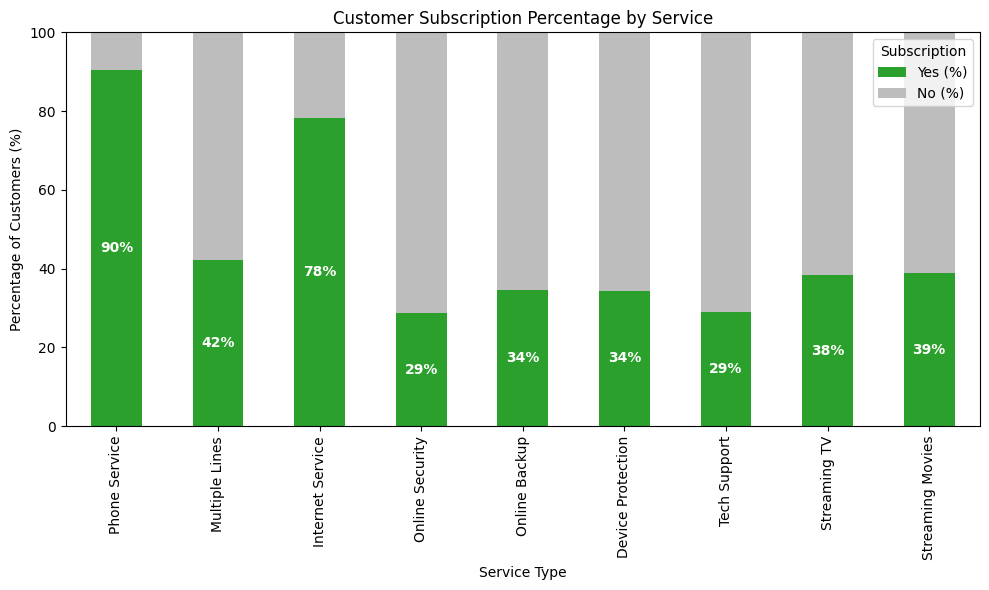

Total customer: 7043


In [ ]:
ax = summary.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#2CA02C', '#BDBDBD']
)

plt.ylabel('Percentage of Customers (%)')
plt.xlabel('Service Type')
plt.title('Customer Subscription Percentage by Service')
plt.legend(title='Subscription')
plt.ylim(0, 100)


for i, yes_pct in enumerate(summary['Yes (%)']):
    ax.text(
        i,
        yes_pct / 2,
        f'{yes_pct:.0f}%',
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

tot_cst = df['CustomerID'].value_counts().sum()
print(f"Total customer: {tot_cst}")

#**4.B. Insights from Categorical Data Visualization:**

- **Primary Service Adoption:** Phone services represent the most widely utilized offering, with a substantial 90% adoption rate among the customer base. This is followed by Internet services, which are utilized by 78% of the total clientele.

- **Secondary Service Distribution:** In contrast, other service offerings exhibit significantly lower engagement levels. Each of these remaining services fails to reach a 50% utilization threshold among the users.

#**5.A. Data Storytelling through Visualization**

**Case Study: Analyzing Customer Behavioral Patterns Based on Dependents (Partners, Senior Citizens, and Children)**

**1. Service Adoption Patterns:** What are the total quantities and specific categories of services utilized by customers with dependents?

**2. Customer Retention (Tenure):** How does the presence of dependents influence the overall duration of a customer's subscription?

**3. Risk-Value Distribution:** Where do these specific demographics settle within the matrix that correlates Customer Lifetime Value with churn probability?

To investigate the correlation between dependent status and service usage, tenure, and value metrics, the following analytical framework will be implemented:

**0. Data Preparation**

- Perform **label encoding** on the 'Senior Citizen', 'Partner', and 'Dependents' attributes.

- Construct a derivative column, **'Dependent_Count'**, to aggregate the total number of dependents per account.

- Execute binary encoding for all service-related fields, including 'Phone Service', 'Multiple Lines', 'Internet Service', and related security and streaming features.

**1. Service Utilization and Diversity**

- Generate summary tables to provide an overview of the customer volume within each dependent category, complemented by **pivot tables** correlating customers with specific service types.

- Utilize **horizontal stacked bar charts** to visualize the distribution of service adoption across segments.

- Develop bar charts to compare the **median volume of services** utilized by each customer category.

**2. Subscription Longevity (Tenure Months)**

- Employ **violin plots** to illustrate the density distribution and median tenure duration for each demographic segment, allowing for a nuanced comparison of customer loyalty.

**3. CLTV-Churn Score Matrix Analysis**

- Construct **scatter plots** to map the spatial distribution of customer categories within the CLTV-Churn Score matrix.

- Produce **heat maps** to identify the concentration of specific customer groups, highlighting high-risk or high-value clusters within the matrix.

##**1.A. Service Adoption Patterns**

In [ ]:
df['Dependent_Count'] = (
    (df['Senior Citizen'] == 'Yes').astype(int) +
    (df['Partner'] == 'Yes').astype(int) +
    (df['Dependents'] == 'Yes').astype(int)
)

In [ ]:
df.head(3)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Churn Score Grouped,CLTV Grouped,Churn_bin,CLTV_bin,Dependent_Count
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,1,0,1,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86.0,3239,Competitor made better offer,High-Risk,Lower Med-Value,75–100,3–4k,0
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,1,0,1,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67.0,2701,Moved,Higher Med-Risk,Low-Value,50–75,2–3k,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,1,1,1,0,0,1,0,1,1,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86.0,5372,Moved,High-Risk,High-Value,75–100,5k+,1


In [ ]:
df[['Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies']] = df[['Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies']].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   CustomerID           7043 non-null   object  
 1   Count                7043 non-null   object  
 2   Country              7043 non-null   object  
 3   State                7043 non-null   object  
 4   City                 7043 non-null   object  
 5   Zip Code             7043 non-null   object  
 6   Lat Long             7043 non-null   object  
 7   Latitude             7043 non-null   float64 
 8   Longitude            7043 non-null   float64 
 9   Gender               7043 non-null   object  
 10  Senior Citizen       7043 non-null   object  
 11  Partner              7043 non-null   object  
 12  Dependents           7043 non-null   object  
 13  Tenure Months        7043 non-null   int64   
 14  Phone Service        7043 non-null   int64   
 15  Multiple Lines       

In [ ]:
services = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies'
]

In [ ]:
df_tot_depend1 = df['Dependent_Count'].value_counts()
df_tot_depend1.loc['Total'] = df_tot_depend1.sum(axis=0)
df_tot_depend1

,count
Dependent_Count,
0,2781
1,2415
2,1785
3,62
Total,7043


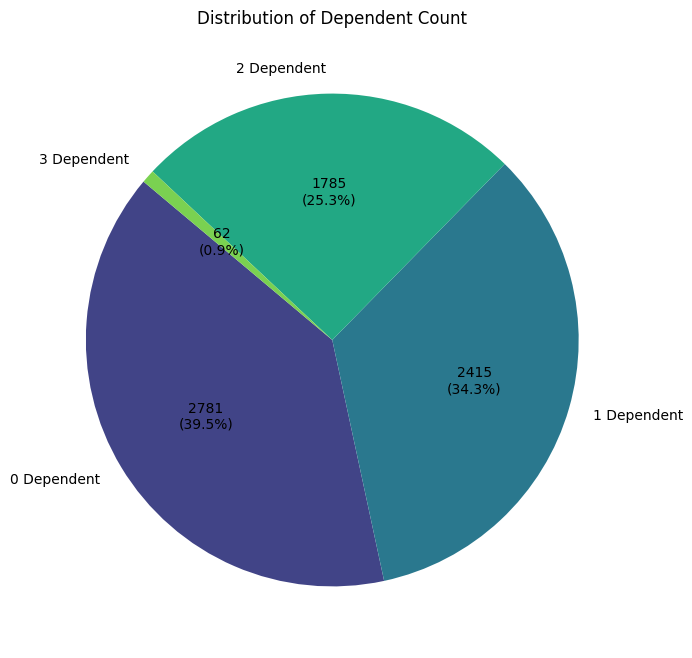

In [ ]:
df_tot_depend1 = df['Dependent_Count'].value_counts()
df_tot_depend1 = df_tot_depend1.rename({
    0: '0 Dependent',
    1: '1 Dependent',
    2: '2 Dependent',
    3: '3 Dependent'})


def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val:d}\n({pct:.1f}%)'
    return my_autopct

plt.figure(figsize=(8, 8))

plt.pie(
    df_tot_depend1,
    labels=df_tot_depend1.index,
    autopct=make_autopct(df_tot_depend1),
    startangle=140,
    colors=sns.color_palette('viridis', n_colors=len(df_tot_depend1)))

plt.title('Distribution of Dependent Count')
plt.show()

In [ ]:
order = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies'
]

pivot_services = pd.pivot_table(
    df,
    index='Dependent_Count',
    values=services,
    aggfunc='sum')

pivot_services.loc['Total'] = pivot_services.sum(axis=0)
pivot_services = pivot_services[order]

pivot_services

,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
Dependent_Count,,,,,,,,,
0,2499,912,2120,629,746,752,693,861,882
1,2179,1163,2035,779,947,948,771,1090,1093
2,1629,858,1303,593,703,693,561,723,723
3,54,38,59,18,33,29,19,33,34
Total,6361,2971,5517,2019,2429,2422,2044,2707,2732


In [ ]:
pivot_services = df.groupby('Dependent_Count')[services].sum()

summary_pct = pivot_services.div(pivot_services.sum(axis=0), axis=1) * 100

summary_pct = summary_pct.round(1)

summary_pct


,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
Dependent_Count,,,,,,,,,
0,39.3,30.7,38.4,31.2,30.7,31.0,33.9,31.8,32.3
1,34.3,39.1,36.9,38.6,39.0,39.1,37.7,40.3,40.0
2,25.6,28.9,23.6,29.4,28.9,28.6,27.4,26.7,26.5
3,0.8,1.3,1.1,0.9,1.4,1.2,0.9,1.2,1.2


In [ ]:
custom_cmap = ListedColormap(['#414487', '#2a788e', '#22a884', '#7ad151'])

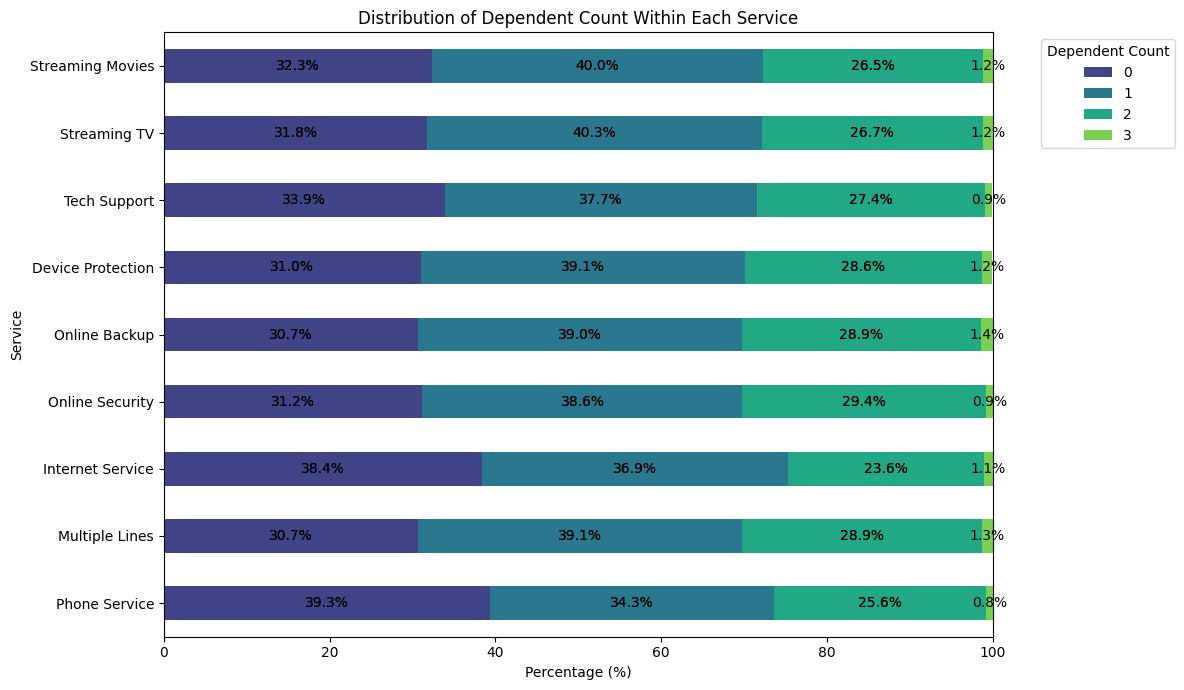

In [ ]:
plot_data = summary_pct.T

ax = plot_data.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 7),
    cmap=custom_cmap
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center')


plt.xlabel('Percentage (%)')
plt.ylabel('Service')
plt.title('Distribution of Dependent Count Within Each Service')
plt.legend(title='Dependent Count', bbox_to_anchor=(1.05, 1))
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

##**1.B. Service Adoption Patterns**

In [ ]:
service_cols = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies']

df['Service_Count'] = df[service_cols].sum(axis=1)

In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Churn Score Grouped,CLTV Grouped,Churn_bin,CLTV_bin,Dependent_Count,Service_Count
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,1,0,1,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86.0,3239,Competitor made better offer,High-Risk,Lower Med-Value,75–100,3–4k,0,4
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,1,0,1,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67.0,2701,Moved,Higher Med-Risk,Low-Value,50–75,2–3k,1,2
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,1,1,1,0,0,1,0,1,1,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86.0,5372,Moved,High-Risk,High-Value,75–100,5k+,1,6
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,1,1,1,0,0,1,1,1,1,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84.0,5003,Moved,High-Risk,High-Value,75–100,5k+,2,7
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,1,1,1,0,1,1,0,1,1,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89.0,5340,Competitor had better devices,High-Risk,High-Value,75–100,5k+,1,7


In [ ]:
pivot_tot_services = pd.pivot_table(
    df,
    index='Dependent_Count',
    values='Service_Count',
    aggfunc=['mean','median'])

pivot_tot_services.round(2)

,mean,median
,Service_Count,Service_Count
Dependent_Count,,
0,3.63,3.0
1,4.56,5.0
2,4.36,4.0
3,5.11,5.0


/tmp/ipython-input-3485686722.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.violinplot(


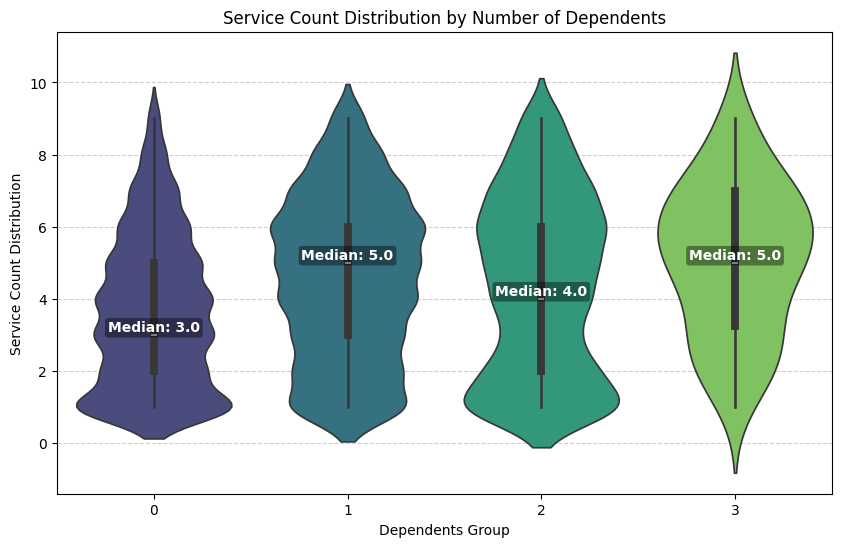

In [ ]:
medians = df.groupby('Dependent_Count')['Service_Count'].median().sort_index()

plt.figure(figsize=(10, 6))


ax2 = sns.violinplot(
    x='Dependent_Count',
    y='Service_Count',
    data=df,
    palette='viridis',
    inner='box')

ax2.set_axisbelow(True)
ax2.yaxis.grid(True, linestyle='--', alpha=0.6)
ax2.xaxis.grid(False)

plt.xlabel('Dependents Group')
plt.ylabel('Service Count Distribution')
plt.title('Service Count Distribution by Number of Dependents')


for i, median_val in enumerate(medians):
    ax2.text(
        x=i,
        y=median_val,
        s=f'Median: {median_val:.1f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        color='white',
        fontsize=10,
        bbox=dict(facecolor='black', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.2'))

plt.show()

##**2. Customer Retention (Tenure)**

/tmp/ipython-input-2216431721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.violinplot(data=df, x='Dependent_Count', y='Tenure Months', palette=['#414487', '#2a788e', '#22a884', '#7ad151'])


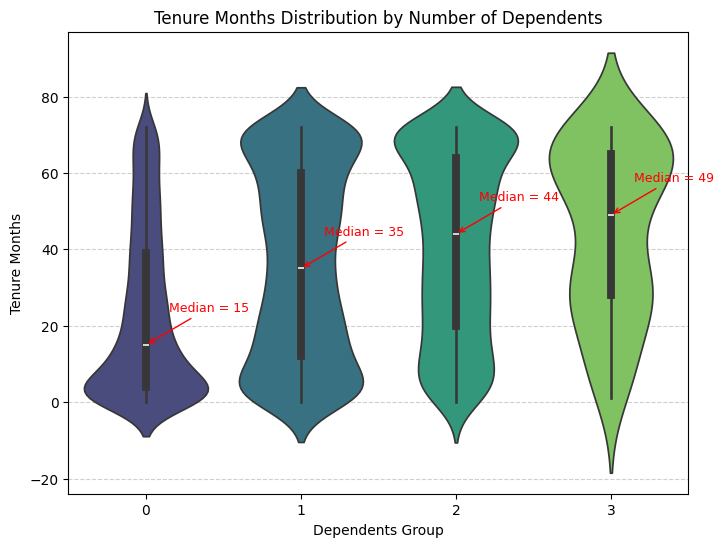

In [ ]:
plt.figure(figsize=(8, 6))
ax3 = sns.violinplot(data=df, x='Dependent_Count', y='Tenure Months', palette=['#414487', '#2a788e', '#22a884', '#7ad151'])

medians = (
    df.groupby('Dependent_Count')['Tenure Months']
      .median())

for i, (dep, median) in enumerate(medians.items()):
    ax3.annotate(
        f'Median = {median:.0f}',
        xy=(i, median),
        xytext=(i + 0.15, median + 8),
        arrowprops=dict(
            arrowstyle='->',
            lw=1,
            color='red'
        ),
        fontsize=9,
        ha='left',
        va='bottom',
        color='red')


ax3.set_xlabel('Dependents Group')
ax3.set_ylabel('Tenure Months')
ax3.set_title('Tenure Months Distribution by Number of Dependents')

ax3.set_axisbelow(True)
ax3.yaxis.grid(True, linestyle='--', alpha=0.6)
ax3.xaxis.grid(False)

##**3. Risk-Value Distribution:**

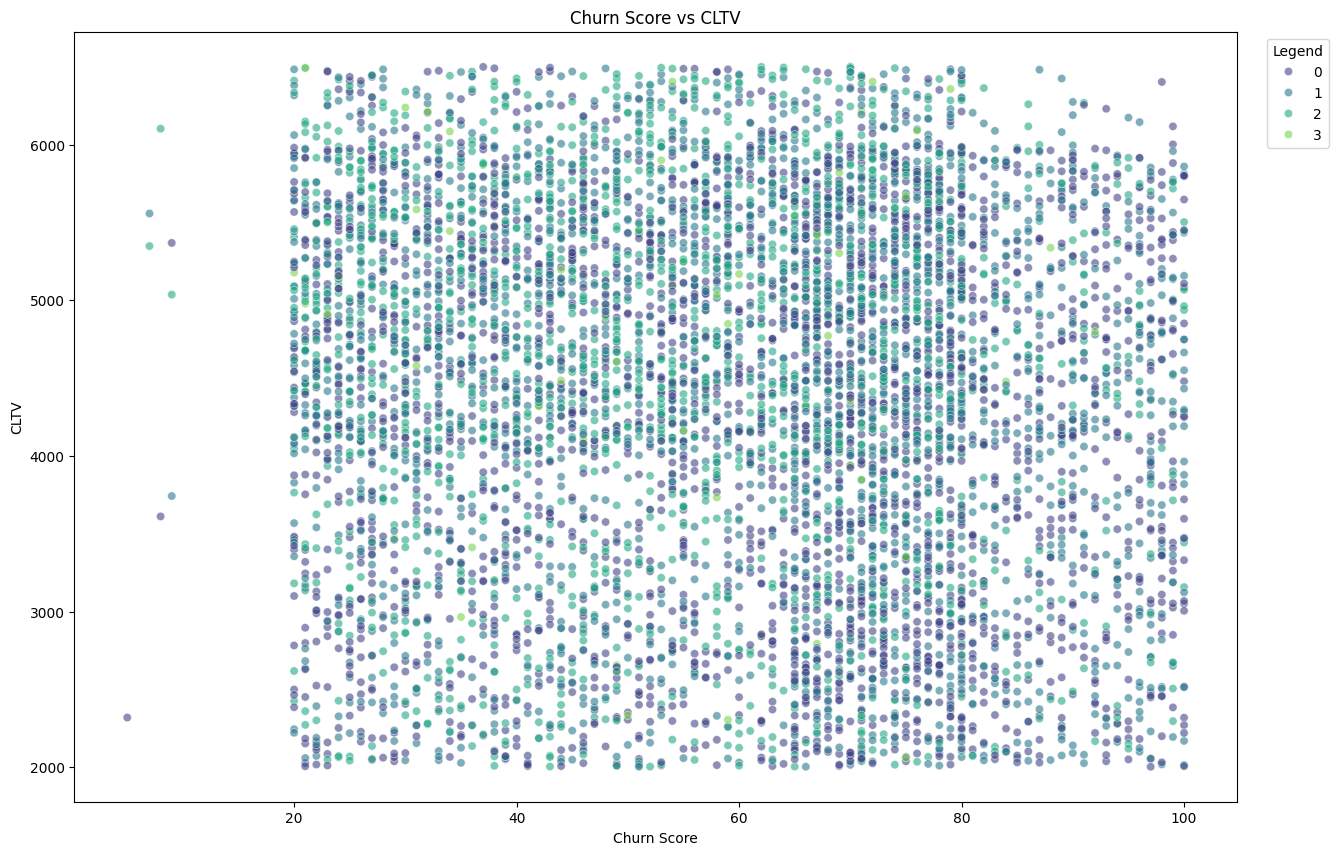

In [ ]:
plt.figure(figsize=(15, 10))

ax4 = sns.scatterplot(
    x='Churn Score',
    y='CLTV',
    hue='Dependent_Count',
    data=df,
    alpha=0.6,
    palette=['#414487', '#2a788e', '#22a884', '#7ad151']
)

plt.xlabel('Churn Score')
plt.ylabel('CLTV')
plt.title('Churn Score vs CLTV')
ax4.legend(title='Legend', bbox_to_anchor=(1.02, 1), loc='upper left')



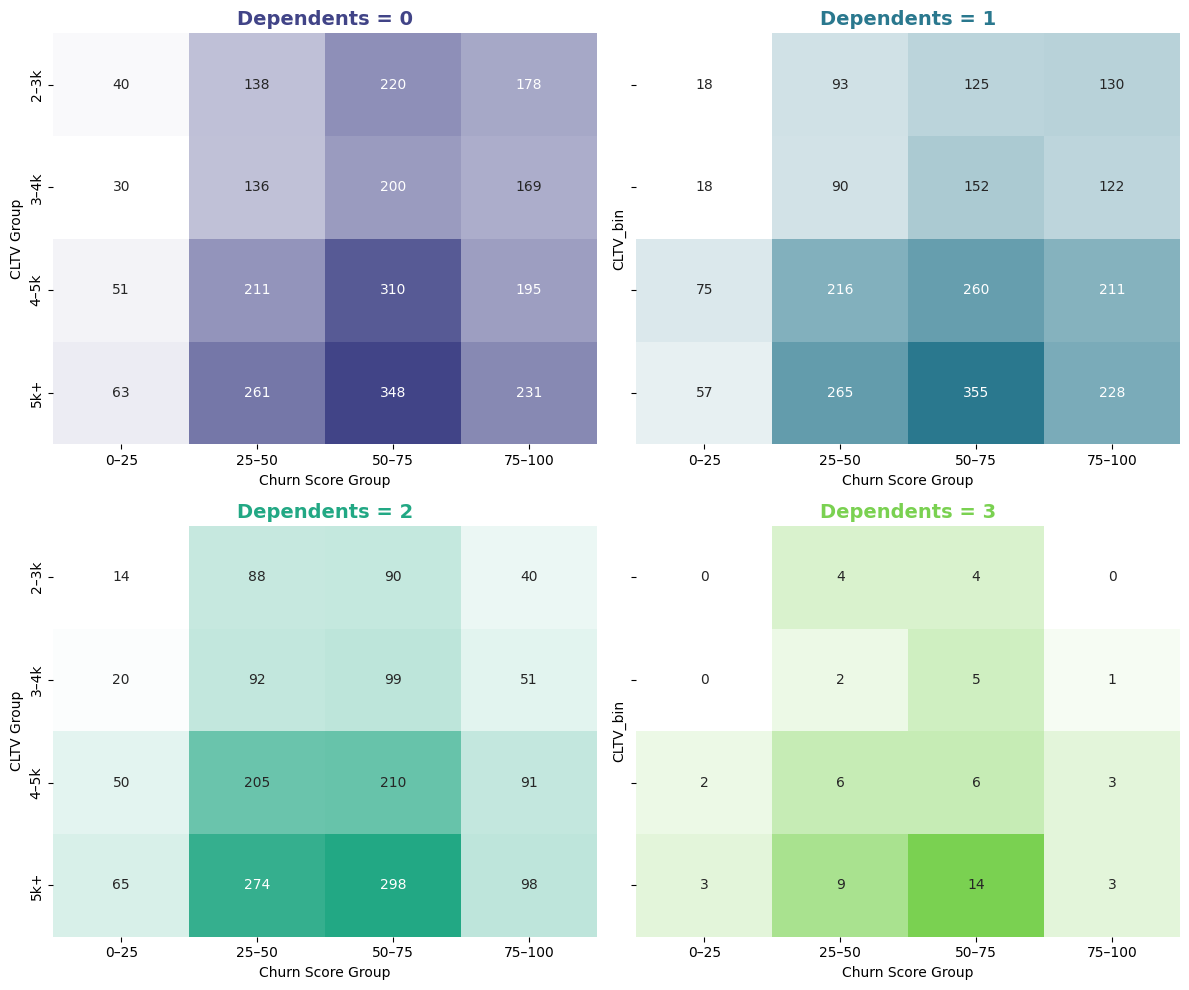

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

deps = sorted(df['Dependent_Count'].unique())

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 10),
    sharey=True)

axes = axes.flatten()
palette_colors = sns.color_palette("viridis", n_colors=len(deps))

colors = {
    dep: palette_colors[i]
    for i, dep in enumerate(deps)}



for ax, dep in zip(axes, deps):
    subset = df[df['Dependent_Count'] == dep]
    heatmap_data = pd.crosstab(
        subset['CLTV_bin'],
        subset['Churn_bin'])

    custom_cmap = LinearSegmentedColormap.from_list(
        f'custom_{dep}',
        ['#ffffff', colors[dep]])

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='d',
        cmap=custom_cmap,
        cbar=False,
        ax=ax)

    ax.set_title(f'Dependents = {dep}', fontsize=14, fontweight='bold', color=colors[dep])
    ax.set_xlabel('Churn Score Group')

axes[0].set_ylabel('CLTV Group')
axes[2].set_ylabel('CLTV Group')

plt.tight_layout()
plt.show()

#**5.B. Insights from Data Storytelling Visualizations**

**Case: How do customer patterns regarding dependents (partners, senior citizens, and children) influence service usage, tenure, and risk?**

**1. Service Adoption and Diversity**
- Demographic Distribution: Out of 7,043 customers, the population is segmented into four categories:

    - Customers with 0 Dependents: 39%
    - Customers with 1 Dependent: 34%
    - Customers with 2 Dependents: 25%
    - Customers with 3 Dependents: 0.9%

- **Service Participation:** It was observed that all demographic segments utilize the full range of nine available service types.

- **Primary Services:** Phone Service and Internet Service remain the most widely adopted offerings across all groups.

- **Secondary Services:** Apart from the two primary services, other offerings maintain a relatively low adoption rate, averaging approximately 2,000 subscribers each.

- **Usage Correlation:** Customers with dependents exhibit a higher propensity to subscribe to multiple services compared to those without. Detailed behavioral observations include:

    - 0 Dependents: High concentration in the 1–3 service range, with density decreasing significantly for more than 3 services (Median = 3).
    - 1 Dependent: Peak density occurs within the 4–5 service range (Median = 5).
    - 2 Dependents: Bimodal distribution with peaks at 1–2 services and 5–6 services (Median = 4).
    - 3 Dependents: Highly concentrated within the 5–7 service range (Median = 5).

**2. Subscription Longevity (Tenure Months)**
- **Loyalty Correlation:** There is a positive correlation between the number of dependents and subscription duration. This suggests that customers with family commitments demonstrate higher loyalty levels than those without dependents.

**3. CLTV-Churn Score Matrix Analysis**
- **Risk Identification:** Across all customer segments, a substantial volume of high-value individuals (High CLTV) is migrating into the 50–75 Churn Score zone, indicating a heightened risk of attrition.

#**Key Take Out for Business Growth**

| No | Key Findings | Strategic Implications |
|----|--------|----------|
| 1 | Higher service adoption among customers with dependents | Develop Family Bundling promotions to capitalize on multi-service usage. |
| 2 | Shorter tenure observed in customers with zero dependents| Implement long-term contract incentives, such as discounted rates for extended subscription commitments. |
| 3 | Significant concentration of high-value customers at risk (High Churn/High CLTV)| Launch a VIP Care Program to provide white-glove service and ensure high-value retention. |
| 5 | Density of high-value customers with moderate churn risk (25-50) | Introduce loyalty programs that offer tiered benefits to prevent these high-spending customers from entering higher risk zones.|